In [1]:
import math
import numpy as np
import scipy.stats as scs
import statsmodels.api as sm
from pylab import mpl, plt

In [2]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

In [3]:
def gen_paths(S0, r, sigma, T, M, I):
    '''Generate Monte Carlo paths for geometric Brownian Motion.

    Parameters 
    ==========
    S0: float
        initial stock/index value
    r: float
        constant short rate
    sigma: float 
        constant volatility
    T: float
        final time horizaon
    M: int
        number of time steps/intervals
    I: int
        number of paths to be simulated

    Returns
    =======
    paths: ndarray, shape (M + 1, I) 
        simulated paths given the parameters
    '''
    dt = T / M
    paths = np.zeros((M + 1, I))
    paths[0] = S0 
    for t in range(1, M + 1):
        rand = np.random.standard_normal(I)
        rand = (rand - rand.mean())/ rand.std()
        paths[t] = paths[t-1] * np.exp((r - 0.5 * sigma ** 2) * dt +
                                       sigma * math.sqrt(dt) * rand)
    return paths

In [4]:
S0 = 100.
r = 0.05
sigma = 0.2
T = 1.0
M = 50
I = 250000
np.random.seed(100)

In [5]:
paths = gen_paths(S0, r, sigma, T, M, I)

In [6]:
S0 * math.exp(r * T)

105.12710963760242

In [7]:
paths[-1].mean()

np.float64(105.1190446825246)

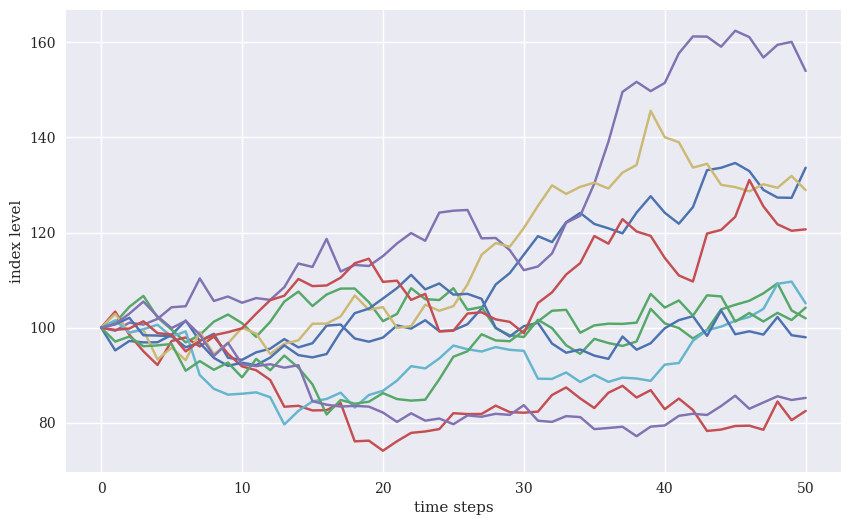

In [8]:
plt.figure(figsize=(10,6))
plt.plot(paths[:, :10])
plt.xlabel('time steps')
plt.ylabel('index level')
plt.show()

In [9]:
paths[:, 0].round(4)

array([100.    ,  95.2123,  97.1885,  96.8957,  96.9154,  98.4583,
       101.5003,  97.2147,  98.6952,  93.6604,  93.2283,  94.7991,
        95.5763,  97.5871,  95.8443,  96.7178, 100.4188, 100.6413,
        97.7141,  97.0397,  97.91  , 100.4595,  99.794 , 101.5602,
        99.2453,  99.4409, 100.7174, 104.0164, 109.0677, 111.4674,
       115.3495, 119.251 , 117.9906, 122.171 , 124.1345, 121.8086,
       120.8928, 119.8405, 124.2044, 127.6481, 124.1695, 121.8624,
       125.3535, 133.1199, 133.6297, 134.6331, 132.9387, 128.9693,
       127.3606, 127.3028, 133.6463])

In [10]:
log_returns = np.log(paths[1:] / paths[:-1])

In [11]:
log_returns[:, 0].round(4)

array([-0.0491,  0.0205, -0.003 ,  0.0002,  0.0158,  0.0304, -0.0431,
        0.0151, -0.0524, -0.0046,  0.0167,  0.0082,  0.0208, -0.018 ,
        0.0091,  0.0376,  0.0022, -0.0295, -0.0069,  0.0089,  0.0257,
       -0.0066,  0.0175, -0.0231,  0.002 ,  0.0128,  0.0322,  0.0474,
        0.0218,  0.0342,  0.0333, -0.0106,  0.0348,  0.0159, -0.0189,
       -0.0075, -0.0087,  0.0358,  0.0273, -0.0276, -0.0188,  0.0282,
        0.0601,  0.0038,  0.0075, -0.0127, -0.0303, -0.0126, -0.0005,
        0.0486])

In [12]:
def print_statistics(array):
    '''Print selected statistics

    Parameters
    ==========
    array: ndarray
        object to generate statistics on
    '''
    sta = scs.describe(array)
    print('%14s %15s' % ('statistic', 'value'))
    print( 30 * '-')
    print('%14s %15.5f' % ('size', sta[0]))
    print('%14s %15.5f' % ('min', sta[1][0]))
    print('%14s %15.5f' % ('max', sta[1][1]))
    print('%14s %15.5f' % ('mean', sta[2]))
    print('%14s %15.5f' % ('std', np.sqrt(sta[3])))
    print('%14s %15.5f' % ('skew', sta[4]))
    print('%14s %15.5f' % ('kurtosis', sta[5]))  

In [13]:
print_statistics(log_returns.flatten())

     statistic           value
------------------------------
          size  12500000.00000
           min        -0.14449
           max         0.15033
          mean         0.00060
           std         0.02828
          skew         0.00071
      kurtosis         0.00035


In [14]:
log_returns.mean() * M + 0.5 * sigma **2

np.float64(0.05000000000000006)

In [16]:
log_returns.std() * math.sqrt(M)

np.float64(0.20000000000000012)

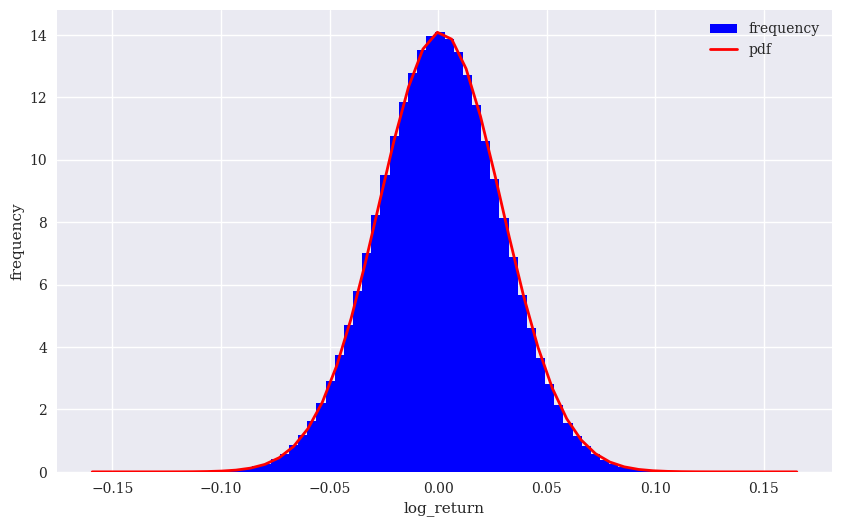

In [17]:
plt.figure(figsize=(10,6))
plt.hist(log_returns.flatten(), bins=70, density=True,
         label='frequency', color='b')
plt.xlabel('log_return')
plt.ylabel('frequency')
x = np.linspace(plt.axis()[0], plt.axis()[1])
plt.plot(x, scs.norm.pdf(x, loc=r / M, scale = sigma / np.sqrt(M)), 'r', 
         lw=2.0, label='pdf')
plt.legend()
plt.show()

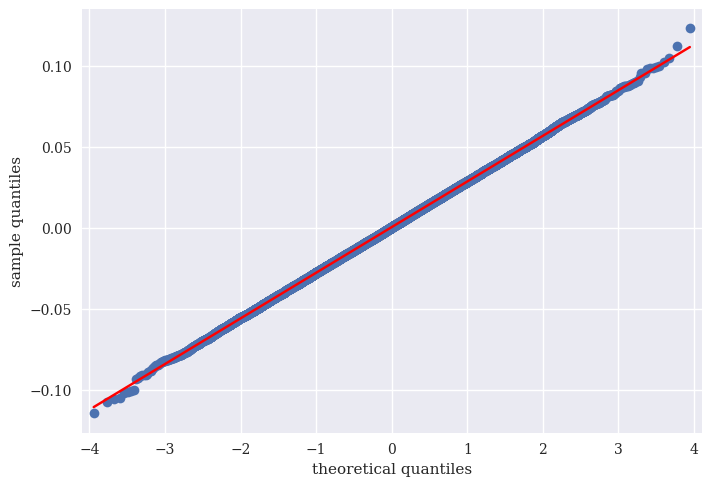

In [18]:
sm.qqplot(log_returns.flatten()[::500], line='s')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.show()

In [21]:
def normality_tests(arr):
    ''' Tests for normality distribution of given data set.

    Parameters
    ==========
    array: ndarray
      object to generate statistics on
    '''
    print('Skew of data set %14.3f' % scs.skew(arr))
    print('Skew test p-value %14.3f' % scs.skewtest(arr)[1])
    print('Kurt of data set %14.3f'  % scs.kurtosis(arr))
    print('Kurt test p-value %14.3f' % scs.kurtosistest(arr)[1])
    print('Norm test p-value %14.3f' % scs.normaltest(arr)[1])

In [22]:
normality_tests(log_returns.flatten())

Skew of data set          0.001
Skew test p-value          0.303
Kurt of data set          0.000
Kurt test p-value          0.802
Norm test p-value          0.570


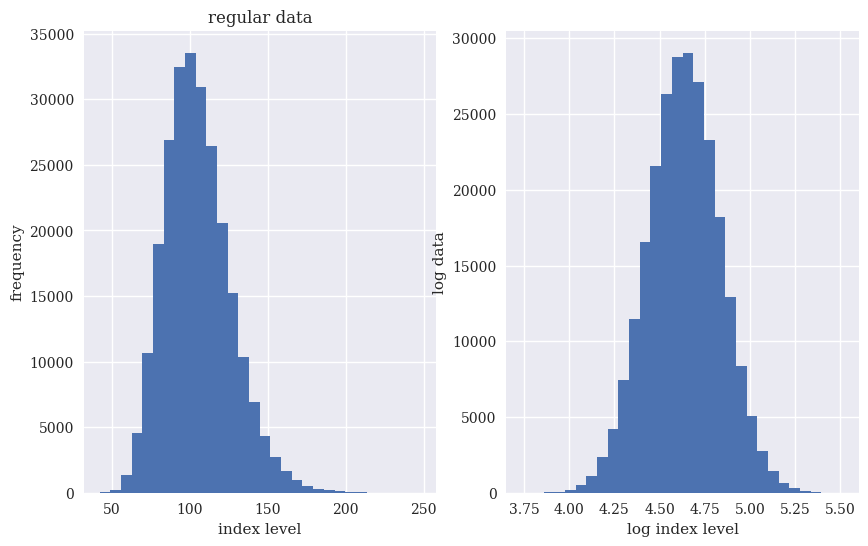

In [25]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(10,6))
ax1.hist(paths[-1], bins=30)
ax1.set_xlabel('index level')
ax1.set_ylabel('frequency')
ax1.set_title('regular data')
ax2.hist(np.log(paths[-1]), bins=30)
ax2.set_xlabel('log index level')
ax2.set_ylabel('log data')
plt.show()

In [26]:
print_statistics(paths[-1])

     statistic           value
------------------------------
          size    250000.00000
           min        42.14320
           max       247.66273
          mean       105.11904
           std        21.18909
          skew         0.60820
      kurtosis         0.65395


In [28]:
print_statistics(np.log(paths[-1]))

     statistic           value
------------------------------
          size    250000.00000
           min         3.74107
           max         5.51207
          mean         4.63517
           std         0.19964
          skew        -0.00308
      kurtosis        -0.00315


In [30]:
normality_tests(np.log(paths[-1]))

Skew of data set         -0.003
Skew test p-value          0.530
Kurt of data set         -0.003
Kurt test p-value          0.753
Norm test p-value          0.781


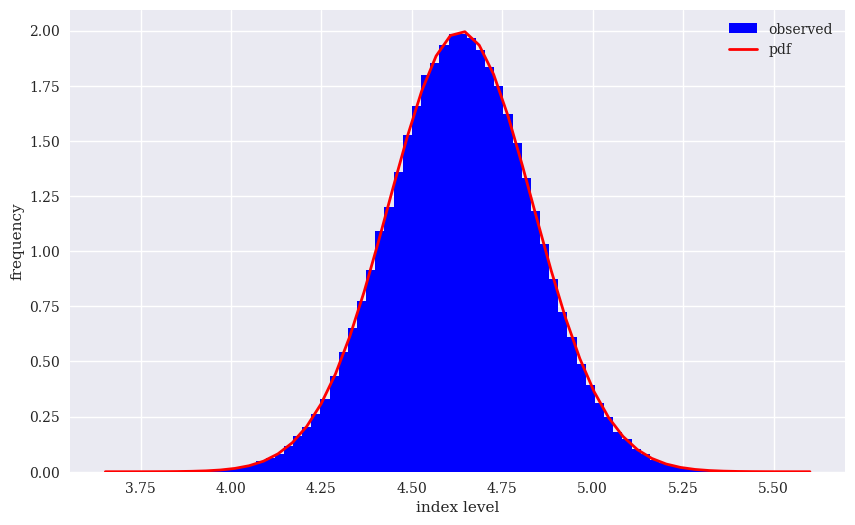

In [33]:
plt.figure(figsize=(10,6))
log_data = np.log(paths[-1])
plt.hist(log_data, bins=70, density=True,
         label='observed', color='b')
plt.xlabel('index level')
plt.ylabel('frequency')
x = np.linspace(plt.axis()[0], plt.axis()[1])
plt.plot(x, scs.norm.pdf(x, log_data.mean(), log_data.std()),
         'r', lw=2.0, label='pdf')
plt.legend()
plt.show()

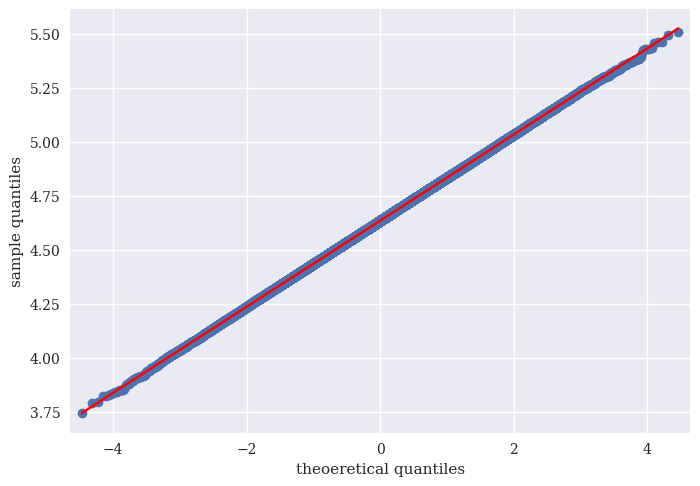

In [37]:
sm.qqplot(log_data, line='s')
plt.xlabel('theoeretical quantiles')
plt.ylabel('sample quantiles')
plt.show()

<span style='font-size:17px'><b>Normality Testing of Simulated GBM Log-Returns</b>

* <b>Simulation Set-up:</b> Using Geometric Brownian Motion with parameters $S_0 = 100$, $r = 0.05$, $\sigma = 0.20$, and a 1-year horizon divided into $M = 50$ time steps, we simulate $I = 250{,}000$ independent price paths - each one a possible future trajectory of the asset - producing a paths matrix of shape $(M+1, I)$.
* <b>Convergence of Monte Carlo Estimator:</b> The theoretical expected terminal price $S_0 e^{rT} \approx
  \textbf{105.127}$ is recovered almost exactly by the average simulated price of $\textbf{105.119}$ -  a discrepancy of less than $0.01\%$. This confirms that with enough paths, the simulation converges to the true mathematical expectation as predicted by the Law of Large Numbers.
* <b>Normality of Log-Returns:</b> Across all $12{,}500{,}000$ log-return observations, skewness is **0.001** and excess kurtosis is <b>0.000</b> - both essentially zero - with all normality test p-values well above <b>0.05</b>. This means we cannot distinguish the simulated returns from true normal distribution, exactly as GBM theory requires.
* <b>Log-Normality of Terminal Prices:</b> The raw terminal prices $S_T$ are right-skewed (skewness <b>0.608</b>), meaning large upside outcomes are more common than large losses - consistent with the fact that prices cannot go below zero. Once we take the log of prices, the skewness collapses to <b>-0.003</b>, confirming that log-prices are normally distibuted as GBM theory predicts.
* <b>Visual Confirmation:</b> The empirical log-returns hostrogram aligns precisely with theoretical normal PDF, and the Q-Q plot - which compares our simulated quantiles against a perfect normal distribution - shows points lying almost exactly on the 45 degree reference line, jointly validating the normality assumption across the full distribution.